The video provided by Netflix ends while buffalo are still entering the frame; therefore, it is possible that we have missed part of the herd in our count. In order to estimate the number of animals we may have missed, we fit a series of regression models to the count data, discretized into 5s bins. We evaluated the fit of each regression model to the observed data and the realism of the forecasted buffalo counts. 

After choosing the best model, we used it to forecast future buffalo crossings using 3 different datasets (discretized into 2, 5, and 10s bins) and three different crossing thresholds, used to determine when the herd "ends".

In [1]:
# Import necessary packages
import pandas as pd
import numpy as np
import pickle
import sys
import os

%matplotlib inline

In [2]:
# Import custom functions
working_dir = os.getcwd()
functions_directory = os.path.join(working_dir, 'functions')
sys.path.append(functions_directory)
from count_forecasting_review import *

In [3]:
# Import tracks
tracks = np.load('data/retained_tracks.npy', allow_pickle = True)

## Create time series of count data

We need to count how many animals cross the count line in each n-second video bin. 
The count line is at a height of 100 pixels. The video is 368 seconds long in total.
We can use the get_bin_counts function to generate counts for different bin lengths.

In [4]:
# Count how many tracks cross the line in each bin
auto_counts_2sec = get_bin_counts(tracks, bin_length = 2)
auto_counts_5sec = get_bin_counts(tracks, bin_length = 5)
auto_counts_10sec = get_bin_counts(tracks, bin_length = 10)

The counts generated above are only for the automatically tracked buffalo. We also need to account for the buffalo missed by the tracking procedure. We have manual counts for 19 video segments. The first 18 segments are 20 seconds long. The last segment is 8 seconds long. We will assume that the manually counted buffalo are crossing the line at a constant rate within each segment.

Note that the manual count for the final segment used here is 4. This count is not including the 15 animals that have entered the frame but have not crossed the count line by the end of the video. Including these 15 animals in the count artificially inflates the count for the last segment (since the count for this analysis specifies the rate at which animals are crossing the count line).

In [5]:
# Import results of manual count and get counts for each bin
manual_data = pd.read_csv('data/manual_count_results.csv')
manual_counts = list(manual_data.groupby(['time_segment'])['manual_count_total'].sum())

In [6]:
# Divide manual counts to get counts for each bin length
man_counts_2sec = get_manual_bin_counts(manual_counts, bin_length = 2)
man_counts_5sec = get_manual_bin_counts(manual_counts, bin_length = 5)
man_counts_10sec = get_manual_bin_counts(manual_counts, bin_length = 10)

In [7]:
# Combine manual and automated counts for each bin
counts_2s = [a+b for a,b in zip(auto_counts_2sec,man_counts_2sec)]
counts_5s = [a+b for a,b in zip(auto_counts_5sec,man_counts_5sec)]
counts_10s = [a+b for a,b in zip(auto_counts_10sec,man_counts_10sec)]

## Define crossing thresholds to determine when the group ends

We need to decide when the herd effectively "ends" - the function we use to predict future crossings will never intersect with 0.
We define thresholds of 0.2, 0.05 and 0.01 buffalo crossing per second of video time, and then count the number of buffalo that are expected to cross the between the end of the video and when the upper posterior predictive interval of our model crosses below each threshold. This gives us a range of expected counts for a given bin size.

In [8]:
# create list of thresholds
thresholds = [0.2, 0.1, 0.05]

## Model exploration
We evaluated three Bayesian regression models:
1. Poisson model with a Gaussian-shaped intensity function
2. Negative Binomial model with Gaussian-shaped intensity funciton
3. Negative Binomial model with a Log-normal intensity function

To evaluate the models, we fit with them using the 5s bin dataset only.

In [55]:
# Fit the three models
model_comparison, fits = compare_models_for_one_series(
    counts=counts_5s,
    bin_width=5,
    speed_factor=3.5,
    real_time_threshold=0.2,
    forecast_seconds=2500,
    random_seed=27,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, mu, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [y_future, y_obs]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, mu, sigma, alpha]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
There were 9 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [y_future, y_obs]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [scale, mu_log, sigma_log, alpha]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [y_future, y_obs]


In [56]:
ppc_PoisGauss = posterior_predictive_check_summary(fits['Poisson-Gaussian'])
ppc_NBGauss = posterior_predictive_check_summary(fits['NB-Gaussian'])
ppc_NBLN = posterior_predictive_check_summary(fits['NB-Lognormal'])
ppc_all = pd.concat([ppc_PoisGauss, ppc_NBGauss, ppc_NBLN], ignore_index = True)
ppc_all

,model,observed_mean,ppc_mean_median,bayesian_p_mean,observed_variance,ppc_variance_median,bayesian_p_variance,observed_max,ppc_max_median,bayesian_p_max,n_observed_points_outside_95_ppi,proportion_observed_points_outside_95_ppi
0,poisson-gaussian,49.175676,49.162162,0.49875,891.790633,244.924658,0.0000,154.0,79.0,0.00000,24,0.324324
1,negative_binomial-gaussian,49.175676,49.763514,0.53875,891.790633,1129.771659,0.7555,154.0,163.0,0.60900,6,0.081081
2,negative_binomial-lognormal,49.175676,48.074324,0.38025,891.790633,1004.682803,0.6650,154.0,149.0,0.43525,6,0.081081


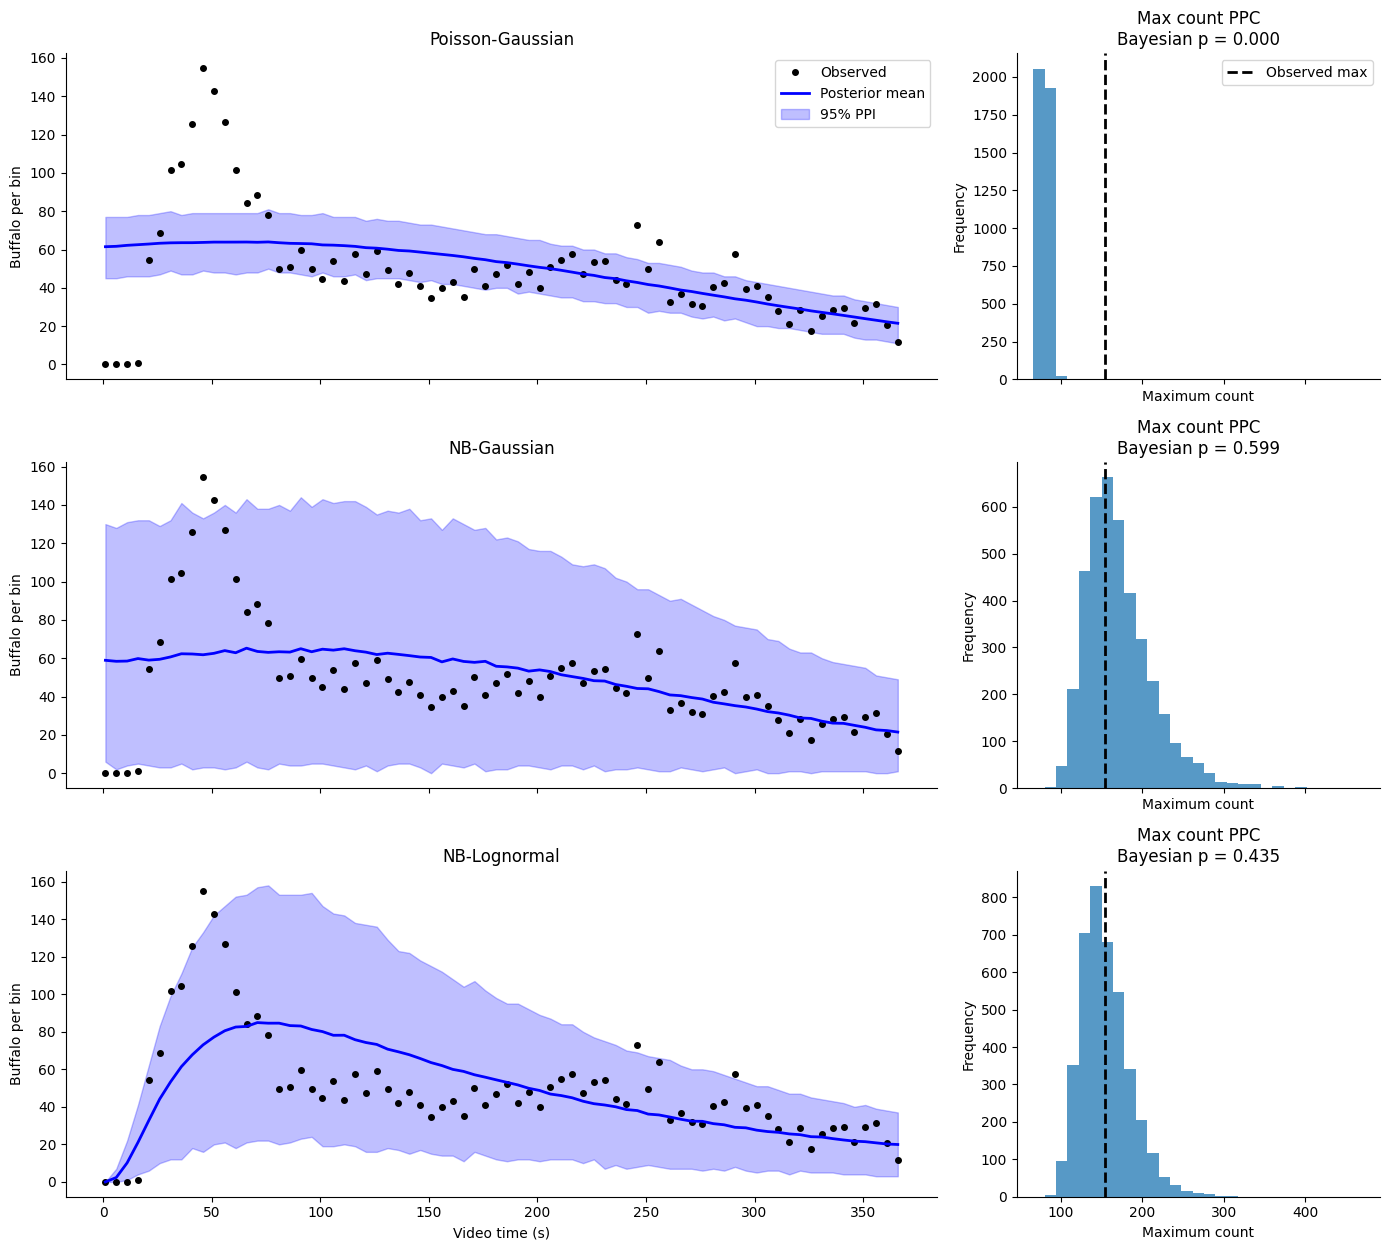

(<Figure size 1400x1260 with 6 Axes>,
 array([[<Axes: title={'center': 'Poisson-Gaussian'}, ylabel='Buffalo per bin'>,
         <Axes: title={'center': 'Max count PPC\nBayesian p = 0.000'}, xlabel='Maximum count', ylabel='Frequency'>],
        [<Axes: title={'center': 'NB-Gaussian'}, ylabel='Buffalo per bin'>,
         <Axes: title={'center': 'Max count PPC\nBayesian p = 0.599'}, xlabel='Maximum count', ylabel='Frequency'>],
        [<Axes: title={'center': 'NB-Lognormal'}, xlabel='Video time (s)', ylabel='Buffalo per bin'>,
         <Axes: title={'center': 'Max count PPC\nBayesian p = 0.435'}, xlabel='Maximum count', ylabel='Frequency'>]],
       dtype=object))

In [57]:
plot_ppc_model_comparison(
    fits=fits,
    counts=counts_5s,
    bin_width=5,
    model_names=("Poisson-Gaussian", "NB-Gaussian", "NB-Lognormal"),
    save=False,
    #filepath="FILEPATH",
)

The Poisson model underestimates the variance in the data. Here we test for and confirm overdispersion in the data, meaning the Poisson model is misspecified.

In [58]:
# Test for overdispersion
disp_2s = summarize_dispersion(counts_2s, label='2 s bins')
disp_5s = summarize_dispersion(counts_5s, label='5 s bins')
disp_10s = summarize_dispersion(counts_10s, label='10 s bins')
pd.concat([disp_2s, disp_5s, disp_10s])

,label,n_bins,mean,variance,variance_to_mean_ratio,overdispersed_relative_to_poisson
0,2 s bins,184,19.934783,147.969494,7.422679,True
0,5 s bins,74,49.621622,896.930211,18.075391,True
0,10 s bins,37,99.297297,3500.325826,35.250968,True


We now compare the future buffalo crossings forecasted by both of the negative binomial models.

In [59]:
model_comparison.iloc[1:]

# Note that this table is generated with a threshold value of 0.2. To generate the values reported in
# Table A4, rerun compare_models_for_one_series() above, with real_time_threshold set to 0.1 and 0.05.

,model,bin_width_s,threshold_crossed_within_window,cutoff_time_video_s,missed_lower_95,missed_mean,missed_upper_95
1,NB-Gaussian,5,True,671.0,1.0,415.06275,1083.0
2,NB-Lognormal,5,True,1176.0,72.0,904.89275,1930.0


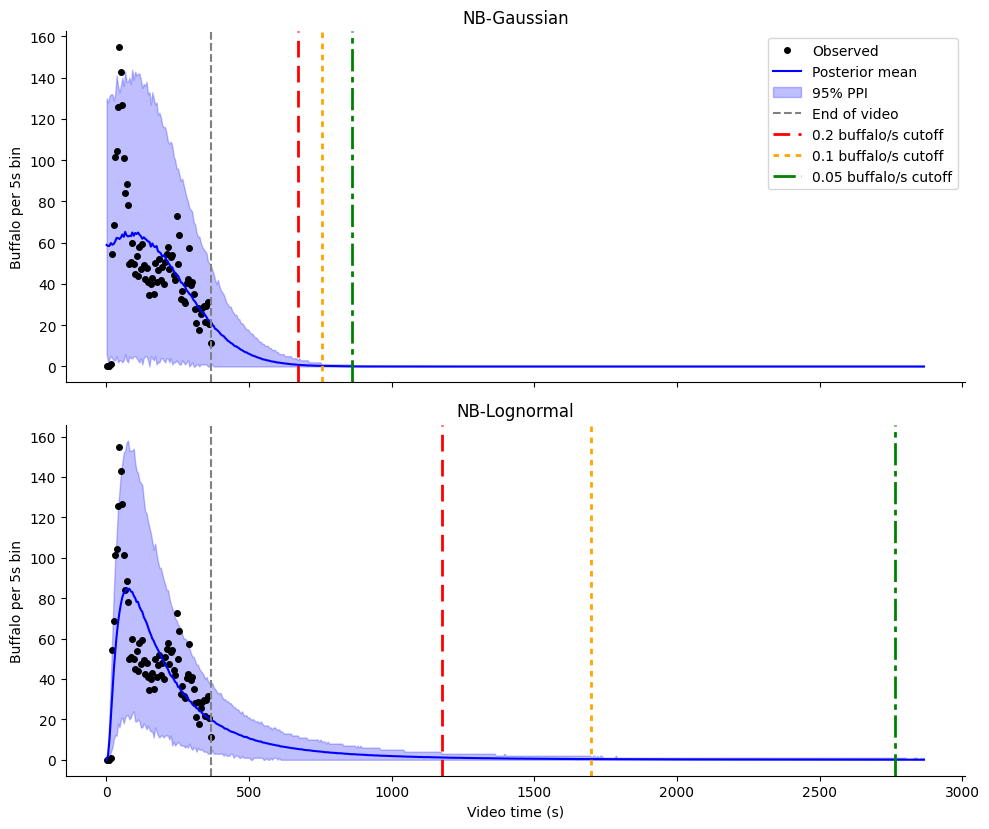

In [61]:
plot_forecast_by_model_5s(
    fits=fits,
    counts=counts_5s,
    forecast_seconds=2500,
    save=False,
    #filepath="FILEPATH",
)

Although the shape of the second model (NB-Lognormal) fits the observed data better, it predicts an extremely long tail describing expected future crossings. We find this protracted crossing window to be unrealistic and thus accept the NB-Gaussian model as our best model.

## Fitting the accepted model and forecasting future buffalo crossings.
We now fit the accepted model to the remaining two time series datasets.

In [14]:
# Fit to 2s data
comparison_table_2s, fits_2s = compare_models_for_one_series(
    counts=counts_2s,
    bin_width=2,
    speed_factor=3.5,
    real_time_threshold=0.2,
    forecast_seconds=500,
    random_seed=27,
)

# Fit to 10s data
comparison_table_10s, fits_10s = compare_models_for_one_series(
    counts=counts_10s,
    bin_width=10,
    speed_factor=3.5,
    real_time_threshold=0.2,
    forecast_seconds=500,
    random_seed=27,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, mu, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [y_future, y_obs]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, mu, sigma, alpha]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Sampling: [y_future, y_obs]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [scale, mu_log, sigma_log, alpha]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [y_future, y_obs]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, mu, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_00

Print posterior predictive check summaries and plot model predictions with observed data for each time series to evaluate model fit.

In [15]:
ppc_2s = posterior_predictive_check_summary(fits_2s["NB-Gaussian"])
ppc_5s = posterior_predictive_check_summary(fits["NB-Gaussian"])
ppc_10s = posterior_predictive_check_summary(fits_10s["NB-Gaussian"])
ppc_table = pd.concat([ppc_2s, ppc_5s, ppc_10s])
ppc_table['bin size'] = ['2s', '5s', '10s']
ppc_table = ppc_table[['bin size', 'model', 'observed_mean', 'ppc_mean_median', 'bayesian_p_mean', 'observed_variance', 'ppc_variance_median', 'bayesian_p_variance', 'observed_max', 'ppc_max_median', 'bayesian_p_max', 'n_observed_points_outside_95_ppi', 'proportion_observed_points_outside_95_ppi']]
ppc_table

,bin size,model,observed_mean,ppc_mean_median,bayesian_p_mean,observed_variance,ppc_variance_median,bayesian_p_variance,observed_max,ppc_max_median,bayesian_p_max,n_observed_points_outside_95_ppi,proportion_observed_points_outside_95_ppi
0,2s,negative_binomial-gaussian,19.543478,19.595109,0.5190,145.550012,154.444167,0.6150,61.0,68.0,0.76925,15,0.081522
0,5s,negative_binomial-gaussian,49.175676,49.729730,0.5420,891.790633,1124.143836,0.7630,154.0,163.0,0.60125,6,0.081081
0,10s,negative_binomial-gaussian,99.027027,101.797297,0.5705,3487.915916,5155.135135,0.7905,280.0,314.0,0.66150,2,0.054054


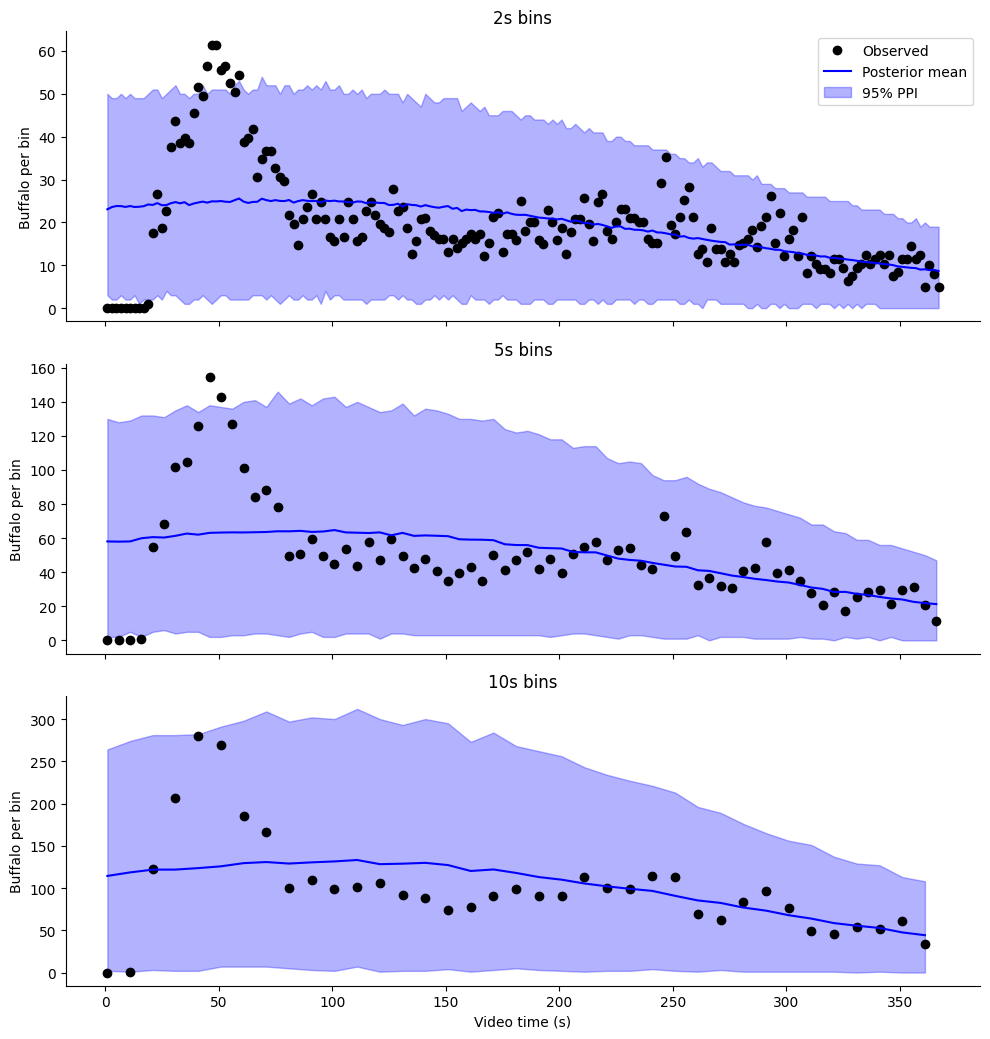

In [16]:
plot_ppc_multi_bin_shared(
    fits_list=[fits_2s, fits, fits_10s],
    counts_list=[counts_2s, counts_5s, counts_10s],
    bin_sizes=[2, 5, 10],
    model_name="NB-Gaussian",  # or "NB-Lognormal" if you want to compare
    save = False
)

Print and plot forecasted crossings for each time series

In [17]:
comparison_table = pd.concat([comparison_table_2s, model_comparison, comparison_table_10s], axis = 0, ignore_index = True)
comparison_table.drop([0,2,3,5,6,8], inplace = True)
comparison_table

,model,bin_width_s,threshold_crossed_within_window,cutoff_time_video_s,missed_lower_95,missed_mean,missed_upper_95
1,NB-Gaussian,2,True,689.0,1.0,450.7715,1159.0
4,NB-Gaussian,5,True,681.0,2.0,419.6055,1101.0
7,NB-Gaussian,10,True,691.0,0.0,431.9620,1232.0


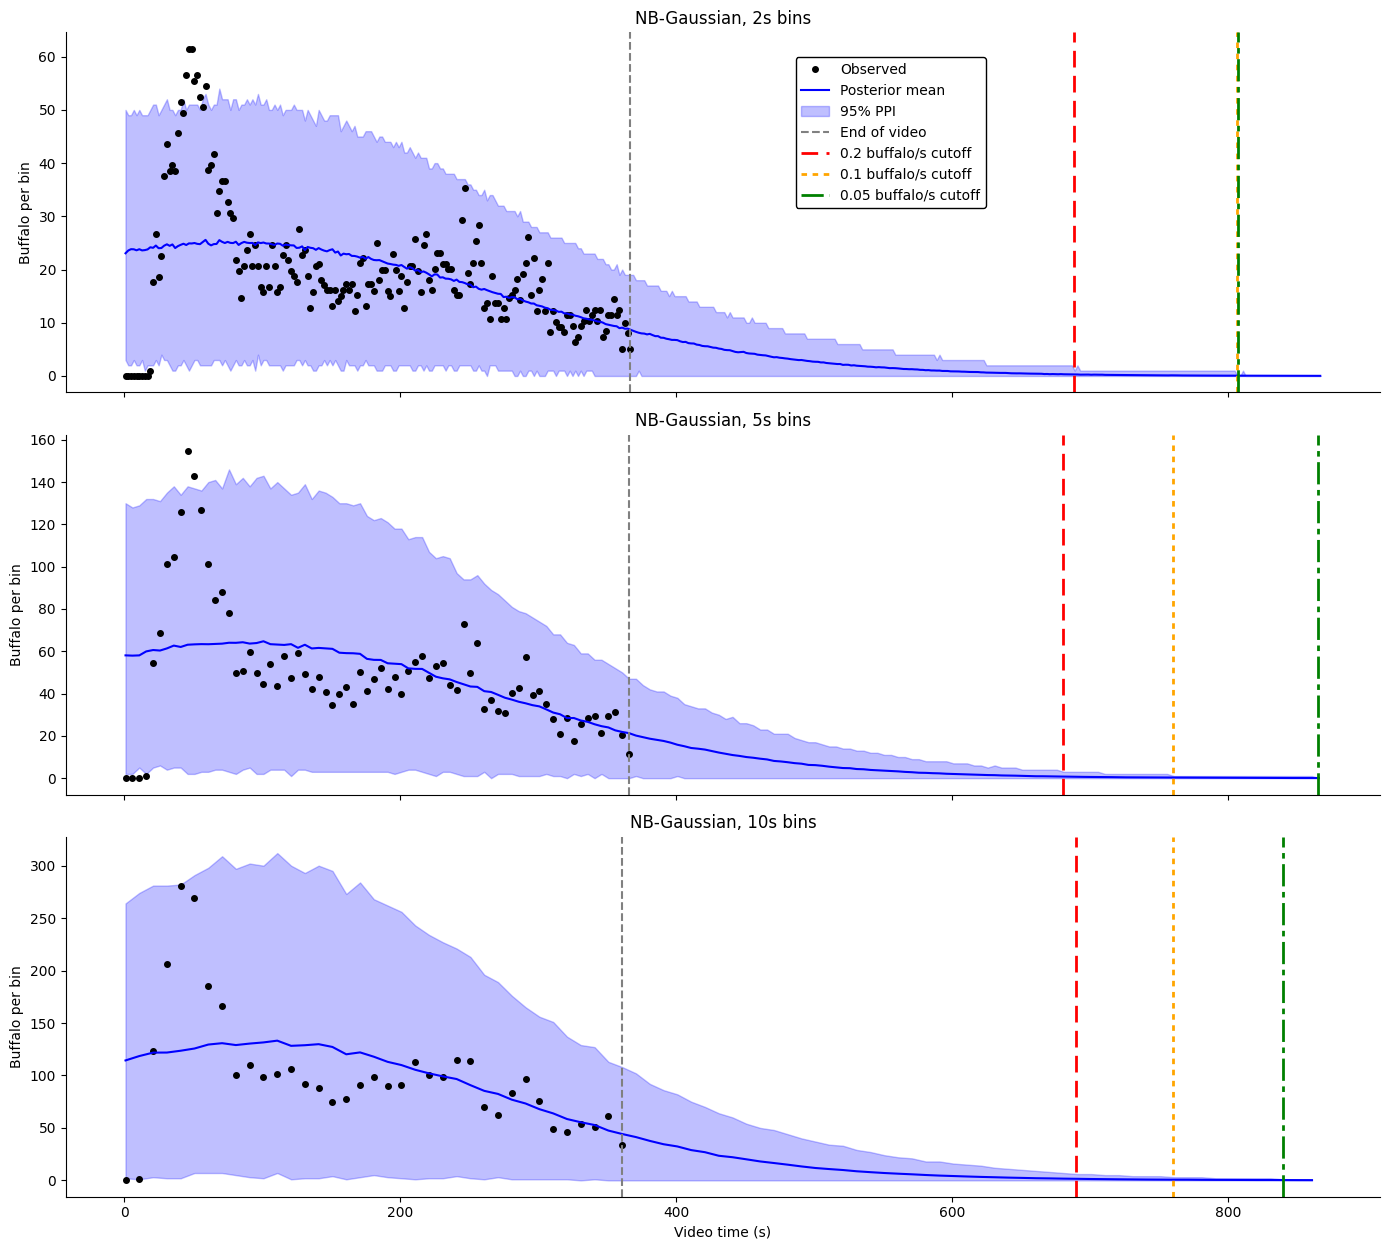

(<Figure size 1400x1260 with 3 Axes>,
 array([<Axes: title={'center': 'NB-Gaussian, 2s bins'}, ylabel='Buffalo per bin'>,
        <Axes: title={'center': 'NB-Gaussian, 5s bins'}, ylabel='Buffalo per bin'>,
        <Axes: title={'center': 'NB-Gaussian, 10s bins'}, xlabel='Video time (s)', ylabel='Buffalo per bin'>],
       dtype=object))

In [18]:
plot_forecast_by_bin_size(
    fits_list=[fits_2s, fits, fits_10s],
    counts_list=[counts_2s, counts_5s, counts_10s],
    bin_sizes=[2, 5, 10],
    model_name="NB-Gaussian",
    save=False,
    #filepath="FILEPATH",
)